In [1]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

from transformers_sae import _autoreload

# from transformers_sae import _autoreload
from transformers_sae.ops import MemoryTrackingMode
from transformers_sae.replacement_model import GemmaReplacement, make_replacement_model

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 2
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 2

model_id = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
training_dataset = load_dataset(
    "monology/pile-uncopyrighted-parquet",
    split="train",
    streaming=True,
    columns=["text"],
)
validation_dataset = load_dataset(
    "monology/pile-test-val",
    split="validation",
    revision="refs/convert/parquet",
    streaming=True,
    columns=["text"],
)

with MemoryTrackingMode() as mtm:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map=TRAINING_DEVICE,
        dtype=torch.bfloat16,
        use_safetensors=True,
    )
    model = make_replacement_model(
        model,
        {},
        num_layers=model.config.num_hidden_layers,
        context_length=1024,  # model.config.max_position_embeddings,
        d_model=model.config.hidden_size,
        layer_path="model.layers",
        replacement_class=GemmaReplacement,
    )
    model.eval()
    model.requires_grad_(False)

print(model)
print(mtm.memory_max)
print(mtm.memory_cur)

/cloud-dev/.venv/lib/python3.13/site-packages/codefind/registry.py:46: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(obj, types.FunctionType):


Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

GemmaReplacementInstance(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (pre_feedforward_layernorm): Gemm

In [2]:
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
# to match Gemma Scope
D_SAE = 16384
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

In [14]:
from concurrent.futures import ThreadPoolExecutor

from transformers_sae.ops import find_latest_checkpoint, load_checkpoint
from transformers_sae.sae_lens_wrapper import wrap_sae_lens_pretrained

checkpoint_dir = "/workspace/sae_checkpoints/gemma_2_2b/next_layer/"

saes = {}

def load_layer_checkpoint(layer):
    checkpoint = find_latest_checkpoint(checkpoint_dir, layer)
    if checkpoint is not None and "100001788" in checkpoint:
        sae = load_checkpoint(checkpoint).sae
        sae.eval()
        sae.onload()
        print(f"Loaded checkpoint for layer {layer}")
        return layer, sae
    else:
        print(f"No checkpoint found for layer {layer}")
        return layer, None

gemma_scope = {}

def load_gemma_scope(layer):
    sae = wrap_sae_lens_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_16k/canonical",
        device=TRAINING_DEVICE,
    )
    return layer, sae

# Load the latest checkpoints for each layer in parallel
with ThreadPoolExecutor() as executor:
    results = executor.map(load_layer_checkpoint, range(model.num_layers - 1, -1, -1))
    # results = executor.map(load_gemma_scope, range(model.num_layers - 1, -1, -1))
    for layer, sae in results:
        if sae is not None:
            saes[layer] = sae


No checkpoint found for layer 21
No checkpoint found for layer 24
No checkpoint found for layer 23
No checkpoint found for layer 20
No checkpoint found for layer 22
No checkpoint found for layer 19
No checkpoint found for layer 17
No checkpoint found for layer 16
No checkpoint found for layer 18
No checkpoint found for layer 11
No checkpoint found for layer 13
No checkpoint found for layer 12
No checkpoint found for layer 2
No checkpoint found for layer 3
No checkpoint found for layer 15
No checkpoint found for layer 10
No checkpoint found for layer 14
No checkpoint found for layer 4
No checkpoint found for layer 8
No checkpoint found for layer 0
No checkpoint found for layer 9
No checkpoint found for layer 5
No checkpoint found for layer 6
No checkpoint found for layer 7
No checkpoint found for layer 1
Loaded checkpoint for layer 25


In [16]:
import numpy as np

from transformers_sae.validation import run_validations

if "validations" not in globals():
    validations = {}

if "geom_kl" not in globals():
    geom_kl = {}

for start_layer in range(min(saes.keys()), model.num_layers):
    if start_layer in validations:
        continue
    print(f"Running validations for replacement starting at {start_layer}")
    validations[start_layer] = run_validations(
        model,
        tokenizer,
        saes,
        validation_dataset,
        TOKENIZER_BATCH_SIZE,
        2,
        NUM_VALIDATION_TOKENS,
        cache_dir=VALIDATION_CACHE_DIR,
        start_layer=start_layer,
        # eval_layers=[start_layer, model.num_layers],
    )
    geom_kl[start_layer] = np.exp(
        np.mean(
            np.log(np.clip(validations[start_layer].layer_results[model.num_layers].kl, min=1e-9))
        )
    ).item()
    print(geom_kl[start_layer])


Running validations for replacement starting at 25


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.057235583662986755


In [17]:
from transformers_sae.ops import save_validations

save_validations(validations, "/workspace/sae_checkpoints/validations/gemma_2_2b/next_layer/")

In [18]:
import os

from transformers_sae.ops import load_validations

VALIDATION_BASE_PATH = "/workspace/sae_checkpoints/validations/gemma_2_2b"

validation_sources = [
    d for d in os.listdir(VALIDATION_BASE_PATH)
    if os.path.isdir(os.path.join(VALIDATION_BASE_PATH, d))
]

all_validations = {
    name: load_validations(f"{VALIDATION_BASE_PATH}/{name}/")
    for name in validation_sources
}

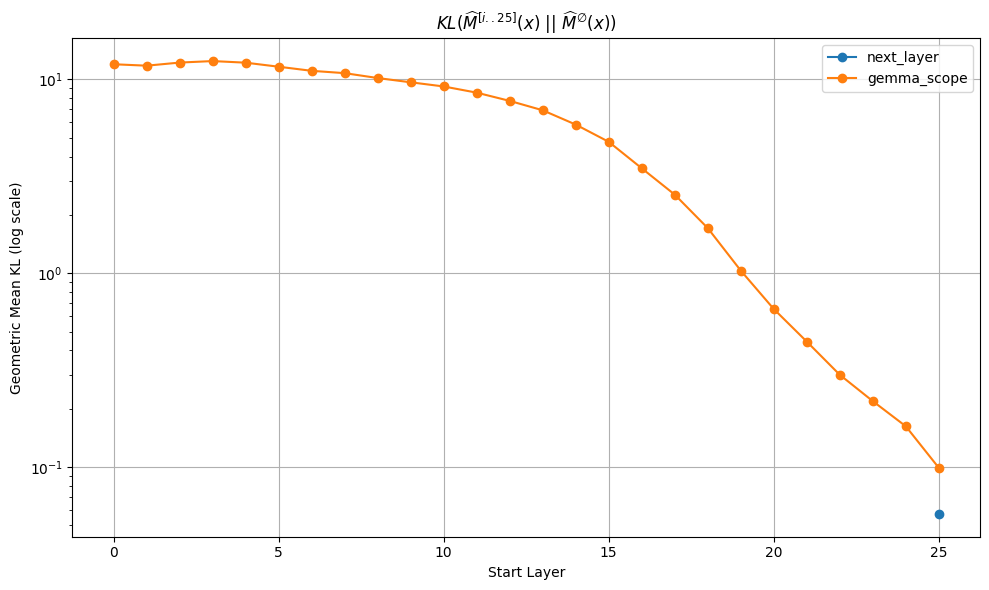

In [19]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg

def compute_geom_kl(validations):
    return {
        layer: np.exp(
            np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
        ).item()
        for layer, v in validations.items()
    }

all_kl = {
    name: compute_geom_kl(validations)
    for name, validations in all_validations.items()
}

plt.figure(figsize=(10, 6))
layers = list(range(0, model.num_layers))

for name, kl_dict in all_kl.items():
    plt.plot(
        layers,
        [kl_dict[layer] if layer in kl_dict else np.nan for layer in layers],
        marker="o",
        label=name,
    )

plt.xlabel("Start Layer")
plt.ylabel("Geometric Mean KL (log scale)")
plt.yscale("log")
plt.title("$KL(\\widehat{{M}}^{{[i..25]}}(x)\\ ||\\ \\widehat{{M}}^{{\\emptyset}}(x))$")
plt.grid(True)
plt.legend()
plt.tight_layout()

# current_plot_to_svg()


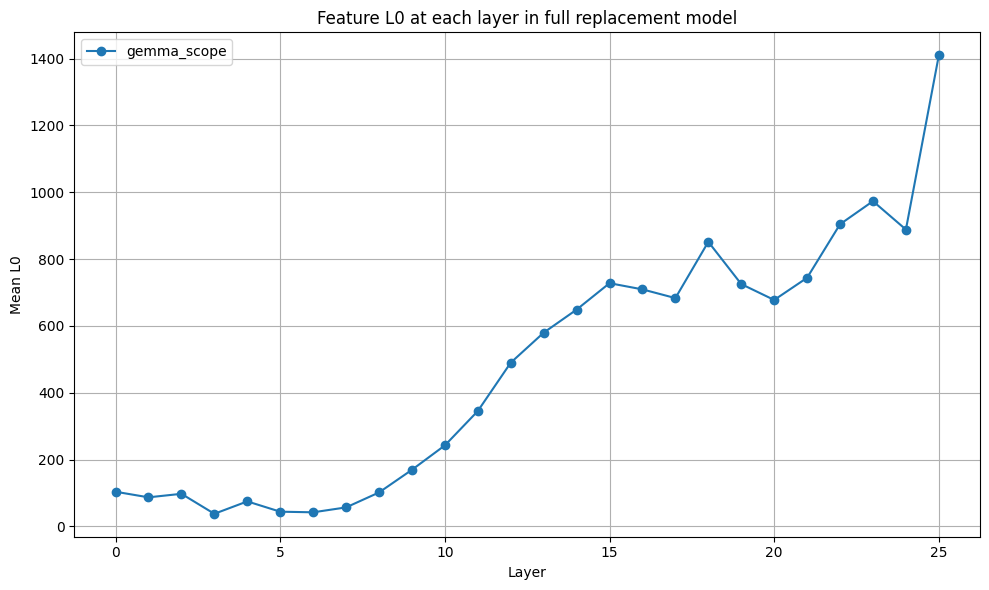

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg

def full_replacement_l0(validations):
    return {
        layer: np.mean(v.l0)
        for layer, v in validations.layer_results.items() if v.l0 is not None
    }

all_l0 = {
    name: full_replacement_l0(validations[min(validations.keys())])
    for name, validations in all_validations.items()
}

layers = list(range(0, model.num_layers))

plt.figure(figsize=(10, 6))

for name, l0_dict in all_l0.items():
    plt.plot(
        layers,
        [l0_dict[layer] if layer in l0_dict else np.nan for layer in layers],
        marker="o",
        label=name,
    )

plt.xlabel("Layer")
plt.ylabel("Mean L0")
plt.title("Feature L0 at each layer in full replacement model")
plt.grid(True)
plt.legend()
plt.tight_layout()

# current_plot_to_svg()


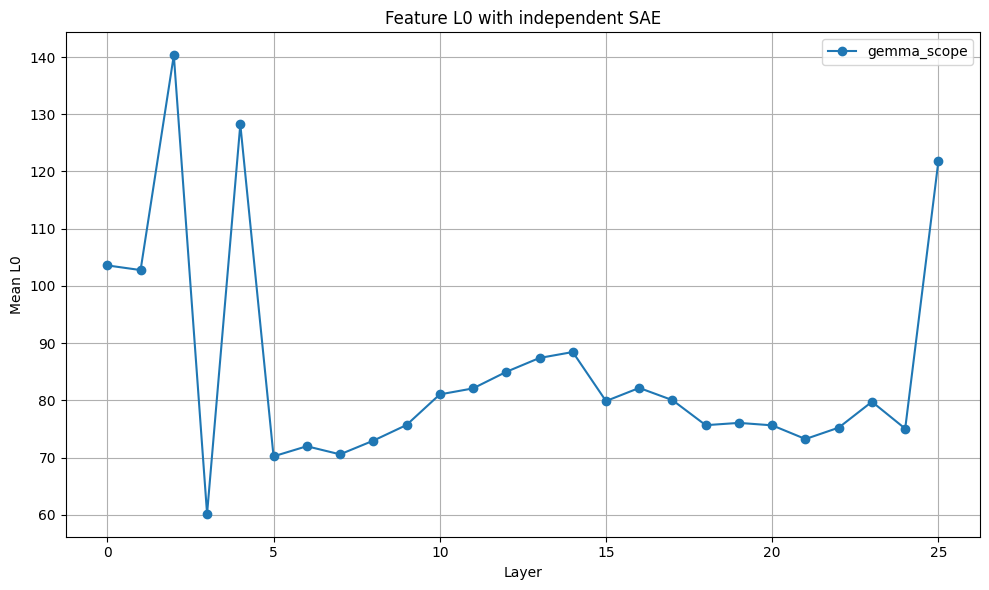

In [9]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg

layers = list(range(0, model.num_layers))

plt.figure(figsize=(10, 6))

for name, validation_dict in all_validations.items():
    plt.plot(
        layers,
        [
            np.mean(validation_dict[layer].layer_results[layer].l0)
            if layer in validation_dict
            else np.nan
            for layer in layers
        ],
        marker="o",
        label=name,
    )

plt.xlabel("Layer")
plt.ylabel("Mean L0")
plt.title("Feature L0 with independent SAE")
plt.grid(True)
plt.legend()
plt.tight_layout()

# current_plot_to_svg()


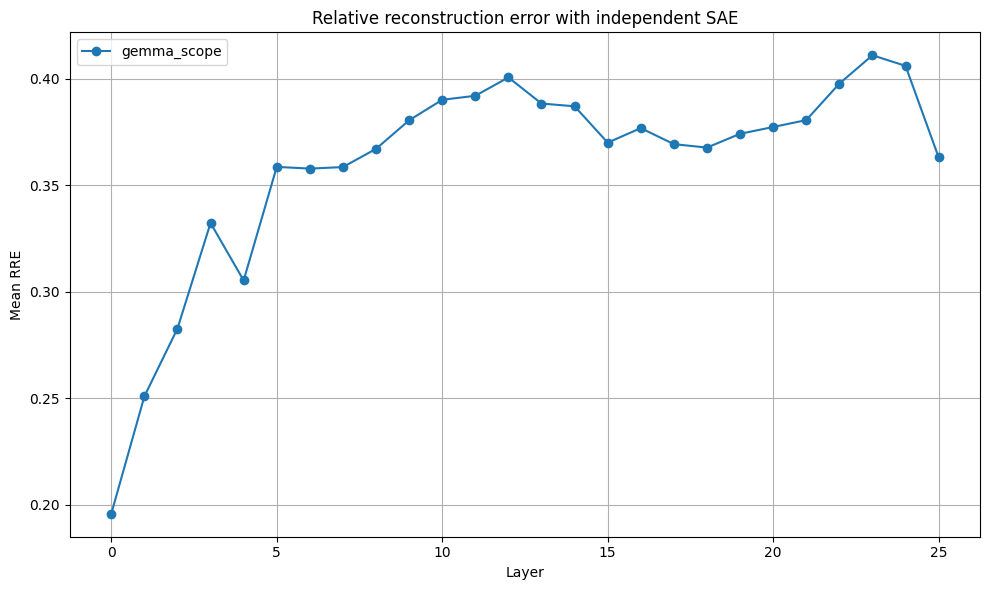

In [10]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg

layers = list(range(0, model.num_layers))

plt.figure(figsize=(10, 6))

for name, validation_dict in all_validations.items():
    plt.plot(
        layers,
        [
            np.mean(validation_dict[layer].layer_results[layer].rre)
            if layer in validation_dict
            else np.nan
            for layer in layers
        ],
        marker="o",
        label=name,
    )

plt.xlabel("Layer")
plt.ylabel("Mean RRE")
plt.title("Relative reconstruction error with independent SAE")
plt.grid(True)
plt.legend()
plt.tight_layout()

# current_plot_to_svg()


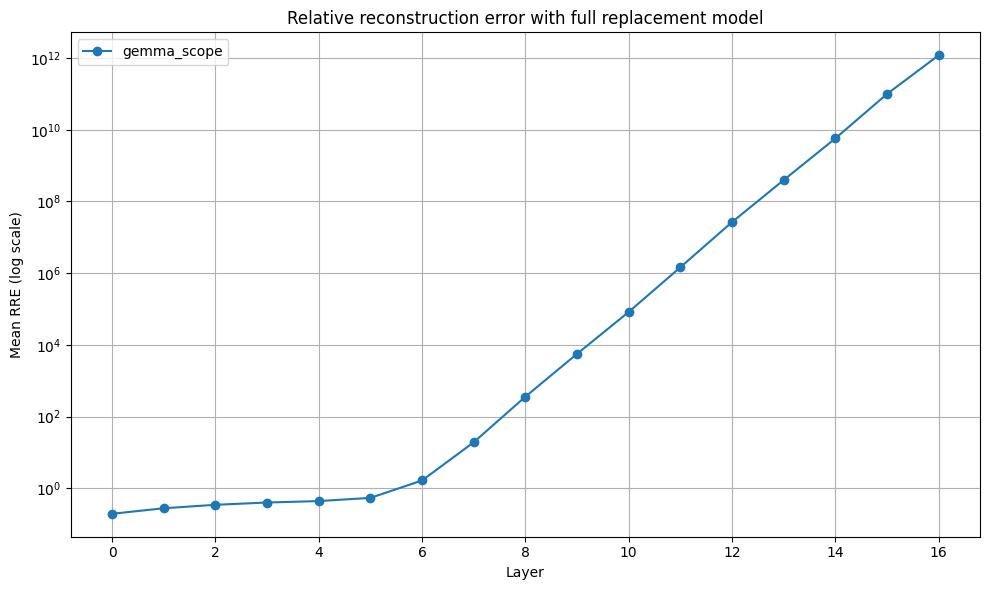

In [11]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg

layers = list(range(0, model.num_layers))

plt.figure(figsize=(10, 6))

for name, validation_dict in all_validations.items():
    plt.plot(
        layers,
        [
            np.mean(validation_dict[min(validation_dict.keys())].layer_results[layer].rre)
            if layer in validation_dict
            else np.nan
            for layer in layers
        ],
        marker="o",
        label=name,
    )

plt.xlabel("Layer")
plt.ylabel("Mean RRE (log scale)")
plt.yscale("log")
plt.title("Relative reconstruction error with full replacement model")
plt.grid(True)
plt.legend()
plt.tight_layout()

# current_plot_to_svg()


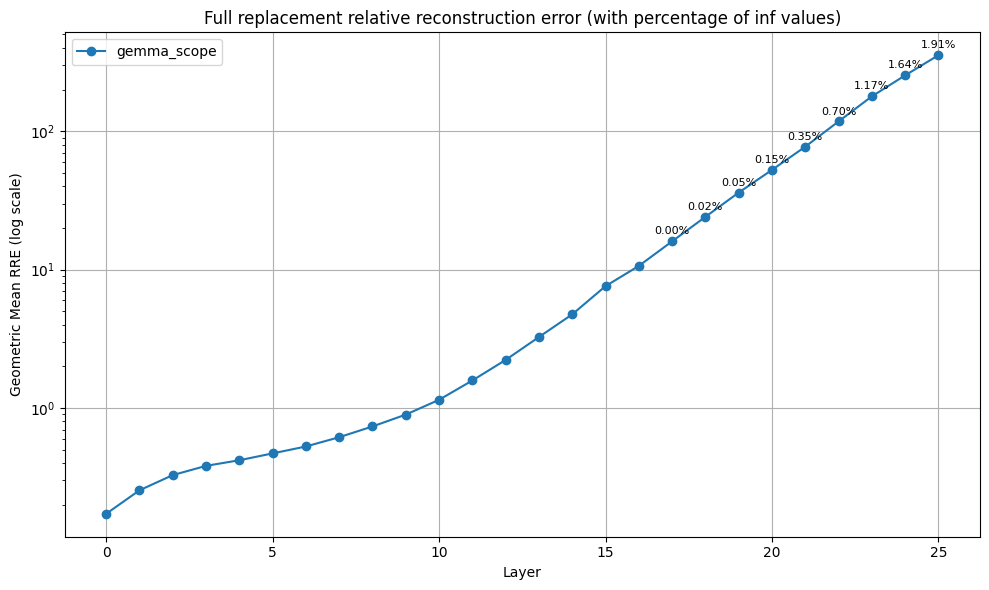

In [13]:
import matplotlib.pyplot as plt
import numpy as np

from transformers_sae.ops import current_plot_to_svg


def compute_geom_rre(validations):
    return {
        layer: (
            np.exp(np.mean(np.log(v.rre[np.isfinite(v.rre)]))).item(),
            np.sum(~np.isfinite(v.rre)) / len(validations.position_ids),
        )
        for layer, v in validations.layer_results.items()
        if v.rre is not None
    }


all_rre = {
    name: compute_geom_rre(validations[min(validations.keys())])
    for name, validations in all_validations.items()
}

plt.figure(figsize=(10, 6))
layers = list(range(0, model.num_layers))

for name, rre_dict in all_rre.items():
    y_values = [rre_dict[layer][0] if layer in rre_dict else np.nan for layer in layers]
    plt.plot(
        layers,
        y_values,
        marker="o",
        label=name,
    )
    for layer in layers:
        if layer in rre_dict:
            inf_frac = rre_dict[layer][1]
            if inf_frac > 0:
                plt.annotate(
                    f"{inf_frac:.2%}",
                    (layer, rre_dict[layer][0]),
                    textcoords="offset points",
                    xytext=(0, 5),
                    ha="center",
                    fontsize=8,
                )

plt.xlabel("Layer")
plt.ylabel("Geometric Mean RRE (log scale)")
plt.yscale("log")
plt.title("Full replacement relative reconstruction error (with percentage of inf values)")
plt.grid(True)
plt.legend()
plt.tight_layout()

# current_plot_to_svg()
